In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will be dynamically set based on num_desired_labels_for_all
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4
        self.DELAY_MEAN = 0.0 # Add DELAY_MEAN as a hyperparameter
        self.NUM_DESIRED_LABELS = 3 # Add NUM_DESIRED_LABELS as a hyperparameter

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65,
                                                keep_prop=0.1,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)
    label_delay_info = []

    for i, label in enumerate(original_labels):
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    label_delay_info.sort(key=lambda x: x[0])

    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True

    return delayed_labels

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch]

        if selected_classes_map:
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    dataloader_kwargs = {
        'dataset': dataset_for_loader,
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

class SNN_rec(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs,
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        if not data: # Handle empty data list case
            return np.array([]), np.array([])
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]
        if len(window) > 0: # Ensure window is not empty
            smoothed_data.append(np.mean(window))
            sem_data.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
        else:
            smoothed_data.append(0.0) # Or NaN, depending on desired behavior for empty window
            sem_data.append(0.0)


    return np.array(smoothed_data), np.array(sem_data)

# --- Training Execution --- BEGIN MODIFICATION

# User-specified delay mean values
delay_mean_param_values = [0.0, 0.1/100, 1/100, 5/100]
num_desired_labels_for_all = config.NUM_DESIRED_LABELS # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# Dynamically set config.NUM_OUTPUTS based on the number of selected classes
config.NUM_OUTPUTS = len(common_selected_classes)
# IMPORTANT: Do NOT re-instantiate config here as it would reset NUM_OUTPUTS to default.

# Initialize results storage for each model type
all_mlp_results = {'acc': {}, 'loss': {}}
all_snn_results = {'acc': {}, 'loss': {}}
all_rec_snn_results = {'acc': {}, 'loss': {}}

for current_delay_mean in delay_mean_param_values:
    print(f"\n--- Training with DELAY_MEAN: {current_delay_mean} ---")

    # Re-create delayed dataloaders for the current delay_mean
    delayed_train_loader_current = create_delayed_dataloader(
        train_loader, delay_mean=current_delay_mean, classes_to_filter=common_selected_classes
    )
    delayed_test_loader_current = create_delayed_dataloader(
        test_loader, delay_mean=current_delay_mean, classes_to_filter=common_selected_classes
    )

    # Instantiate fresh models and optimizers for each delay_mean run
    mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS, num_outputs=config.NUM_OUTPUTS).to(device)
    snn_bp = SNN_MLP(num_outputs=config.NUM_OUTPUTS).to(device)
    rec_snn_bp = SNN_rec(num_outputs=config.NUM_OUTPUTS).to(device)

    mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    # Train MLP
    print(f"Training MLP (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, mlp_bp_tloss, _, mlp_bp_tacc = train_mlp_model(
        mlp_bp, mlp_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_mlp_results['acc'][str(current_delay_mean)] = mlp_bp_tacc
    all_mlp_results['loss'][str(current_delay_mean)] = mlp_bp_tloss

    # Train SNN
    print(f"Training SNN (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, snn_bp_tloss, _, snn_bp_tacc = train_snn_model(
        snn_bp, snn_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_snn_results['acc'][str(current_delay_mean)] = snn_bp_tacc
    all_snn_results['loss'][str(current_delay_mean)] = snn_bp_tloss

    # Train Recurrent SNN
    print(f"Training Recurrent SNN (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, rec_snn_bp_tloss, _, rec_snn_bp_tacc = train_snn_model(
        rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_rec_snn_results['acc'][str(current_delay_mean)] = rec_snn_bp_tacc
    all_rec_snn_results['loss'][str(current_delay_mean)] = rec_snn_bp_tloss


# --- Plot Results --- BEGIN MODIFICATION
SMOOTHING_WINDOW = 20

def plot_model_results(model_name, results_dict, metric_type):
    plt.figure(figsize=(12, 7))

    # Generate a colormap to distinguish delay means
    colors = plt.cm.get_cmap('viridis', len(delay_mean_param_values))

    for i, (delay_mean_str, data) in enumerate(results_dict[metric_type].items()):
        sm_data, sem_data = smooth_curve_with_sem(data, SMOOTHING_WINDOW)
        epochs_range = np.arange(len(sm_data))

        plt.plot(epochs_range, sm_data, label=f'Delay Mean: {float(delay_mean_str):.4f}', color=colors(i))
        plt.fill_between(epochs_range, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

    plt.title(f'Smoothed Test {metric_type.capitalize()} for {model_name} (Window: {SMOOTHING_WINDOW})')
    plt.xlabel('Network Update (Batch)')
    plt.ylabel(metric_type.capitalize())
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plotting for MLP
plot_model_results('MLP (Backprop)', all_mlp_results, 'acc')
plot_model_results('MLP (Backprop)', all_mlp_results, 'loss')

# Plotting for SNN
plot_model_results('SNN (Backprop)', all_snn_results, 'acc')
plot_model_results('SNN (Backprop)', all_snn_results, 'loss')

# Plotting for Recurrent SNN
plot_model_results('Recurrent SNN (Backprop)', all_rec_snn_results, 'acc')
plot_model_results('Recurrent SNN (Backprop)', all_rec_snn_results, 'loss')


snnTorch not found. Installing...


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)
Common classes selected for all loaders: [1, 2, 3]

--- Training with DELAY_MEAN: 0.0 ---
Dataset will be filtered to include *pre-selected* classes: [1, 2, 3]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [1, 2, 3]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Training MLP (Backprop) for DELAY_MEAN=0.0...


/tmp/ipykernel_2513/2560384650.py:282: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


KeyboardInterrupt: 

Generating Sequential Data Loaders...
Selected classes for sequence generation: [8, 9]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 5.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 10.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 20.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Tem

/tmp/ipykernel_1097/3454490921.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


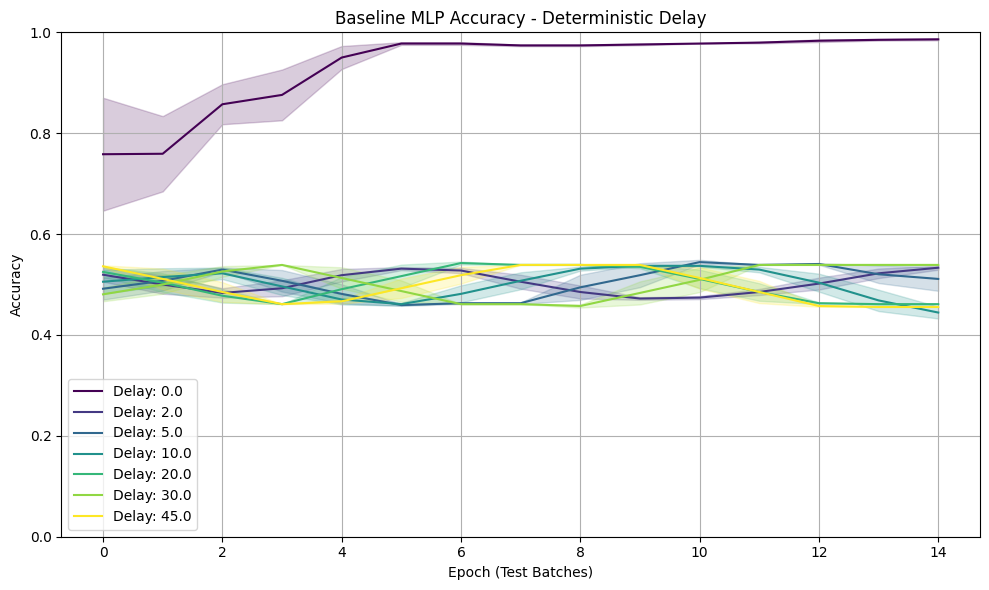

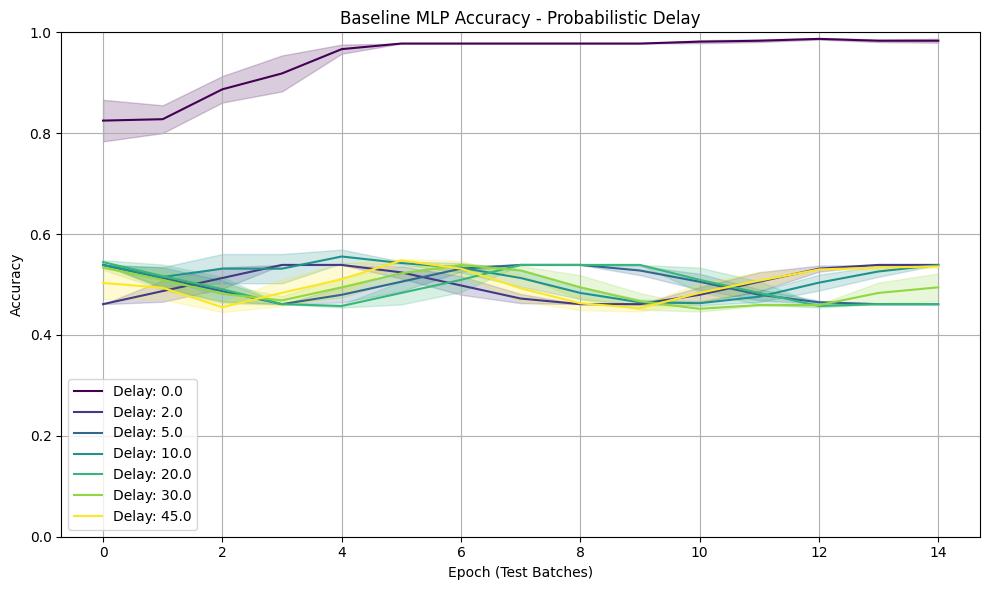

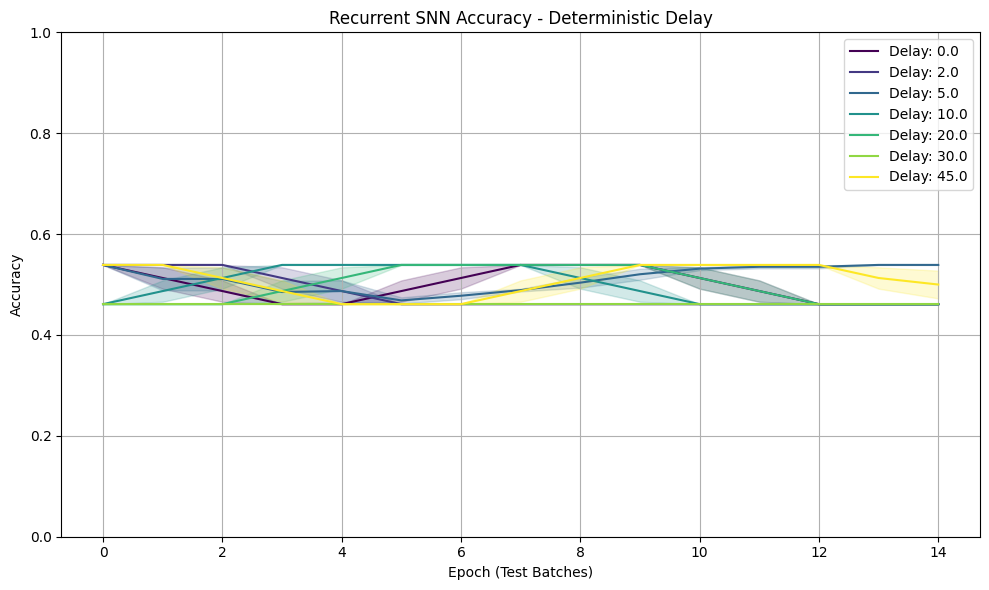

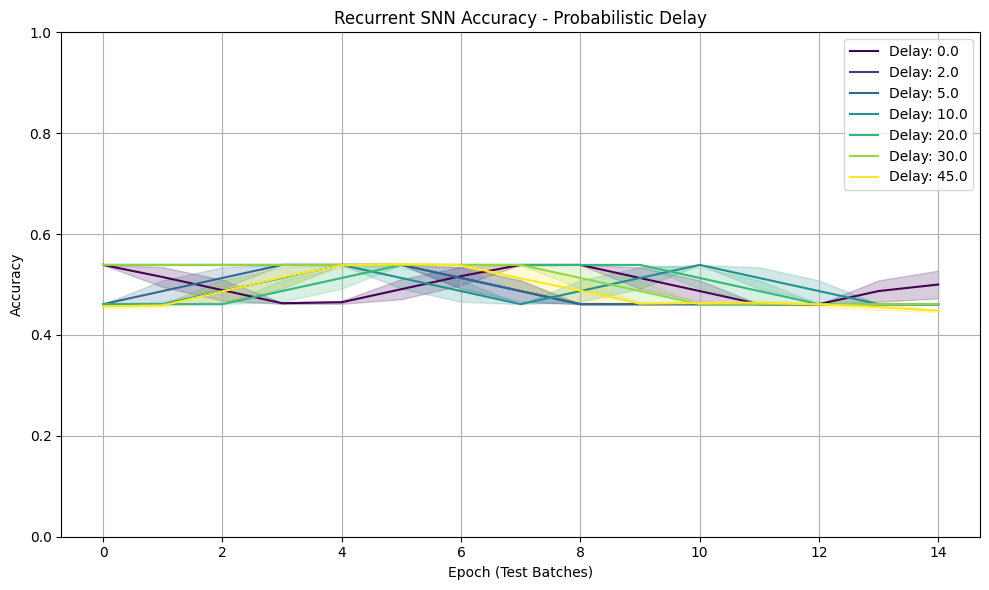

In [ ]:
#@title full experiment

import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 5000
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, explicitly bridging the temporal gap.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate without next(iter()) which triggers StopIteration if empty
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.ylim([0, 1.0])
            plt.tight_layout()
            plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")

--- Running LSTM training for Probabilistic Delay Mean: 1.0 with 2 classes ---
Selected classes for sequence generation: [2, 5]
Training Sequence LSTM...

--- Generating LSTM Evaluation Plot ---


/tmp/ipykernel_2513/831978377.py:308: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(delay_means_for_cmap))


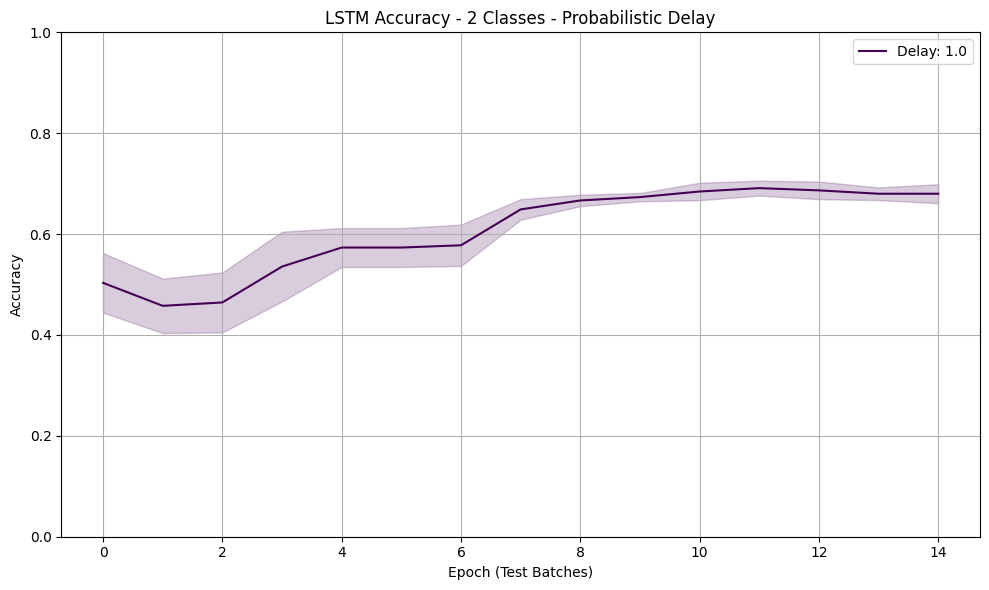

In [ ]:
#@title LSTM
import torch
import torch.nn as nn
import numpy as np
import random
import contextlib
import io
import warnings
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 5000
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate without next(iter()) which triggers StopIteration if empty
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        if not data: # Handle empty data list case
            return np.array([]), np.array([])
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        if len(window) > 0:
            smoothed.append(np.mean(window))
            sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
        else:
            smoothed.append(0.0)
            sem.append(0.0)
    return np.array(smoothed), np.array(sem)

def plot_study_results(results_dict, model_title):
    # Ensure config.DELAY_MEANS is available, otherwise define a default or handle error
    if not hasattr(config, 'DELAY_MEANS'):
        print("Warning: config.DELAY_MEANS not defined. Using default for plotting colormap.")
        delay_means_for_cmap = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0, 45.0] # A reasonable default
    else:
        delay_means_for_cmap = config.DELAY_MEANS

    for delay_type, delays_data in results_dict.items():
        plt.figure(figsize=(10, 6))
        colors = plt.cm.get_cmap('viridis', len(delay_means_for_cmap))

        for i, (delay_str, data) in enumerate(delays_data.items()):
            sm_data, sem_data = smooth_curve_with_sem(data, 3)
            epochs = np.arange(len(sm_data))
            plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
            plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

        plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
        plt.xlabel('Epoch (Test Batches)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()


# Preserve original config values to avoid side effects on other parts of the notebook
original_num_desired_labels = config.NUM_DESIRED_LABELS
original_current_delay_type = config.CURRENT_DELAY_TYPE

# Set new values for this specific experiment
config.NUM_DESIRED_LABELS = 2 # As per "2 classes setting"
specific_delay_mean = 1.0 # As per "1 mean delay"
config.CURRENT_DELAY_TYPE = "probabilistic" # Consistent with previous notebook context

print(f"--- Running LSTM training for {config.CURRENT_DELAY_TYPE.capitalize()} Delay Mean: {specific_delay_mean} with {config.NUM_DESIRED_LABELS} classes ---")

# Get dataloaders with the specific number of classes (config.NUM_DESIRED_LABELS is used by get_dataloaders)
train_loader, test_loader = get_dataloaders()

# --- Define the SequenceLSTM model ---
class SequenceLSTM(nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        # LSTM layer: input_size=NUM_INPUTS, hidden_size=NUM_HIDDEN, batch_first=True for sequence handling
        self.lstm = nn.LSTM(int(num_inputs), num_hidden, batch_first=True) # Cast num_inputs to int
        # Linear layer to map LSTM hidden states to the number of output classes
        self.linear = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        # Flatten image dimensions (C, H, W) into NUM_INPUTS for each timestep
        x_flat = x.view(B, SEQ_LEN, -1)

        # Pass through LSTM layer
        # lstm_out shape: [B, SEQ_LEN, num_hidden]
        lstm_out, _ = self.lstm(x_flat)

        # Apply linear layer to each timestep's output
        # Reshape lstm_out from [B, SEQ_LEN, num_hidden] to [B*SEQ_LEN, num_hidden]
        # Then apply linear, and reshape back to [B, SEQ_LEN, num_outputs]
        preds = self.linear(lstm_out.reshape(-1, lstm_out.size(-1)))
        return preds.view(B, SEQ_LEN, -1)

# Instantiate and train LSTM
print("Training Sequence LSTM...")
# Initialize LSTM with the configured NUM_INPUTS, NUM_HIDDEN, and NUM_OUTPUTS
lstm_model = SequenceLSTM(
    num_inputs=config.NUM_INPUTS,
    num_hidden=config.NUM_HIDDEN,
    num_outputs=config.NUM_DESIRED_LABELS # Use the specific number of classes set for this run
).to(device)

lstm_acc_history = train_sequence_model(lstm_model, train_loader, test_loader, specific_delay_mean)

# Store results for plotting in the format expected by plot_study_results
lstm_results_for_plot = {
    config.CURRENT_DELAY_TYPE: {
        str(specific_delay_mean): lstm_acc_history
    }
}

# Plot the results
print("\n--- Generating LSTM Evaluation Plot ---")
plot_study_results(lstm_results_for_plot, f"LSTM Accuracy - {config.NUM_DESIRED_LABELS} Classes")

# Restore original config values to not affect subsequent cells
config.NUM_DESIRED_LABELS = original_num_desired_labels
config.CURRENT_DELAY_TYPE = original_current_delay_type


snnTorch not found. Installing...
Generating Sequential Data Loaders...


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.50MB/s]


Selected classes for sequence generation: [2, 3]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 5.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 10.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 0.0 (PROBABILISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (PROBABI

/tmp/ipykernel_1569/242447341.py:388: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


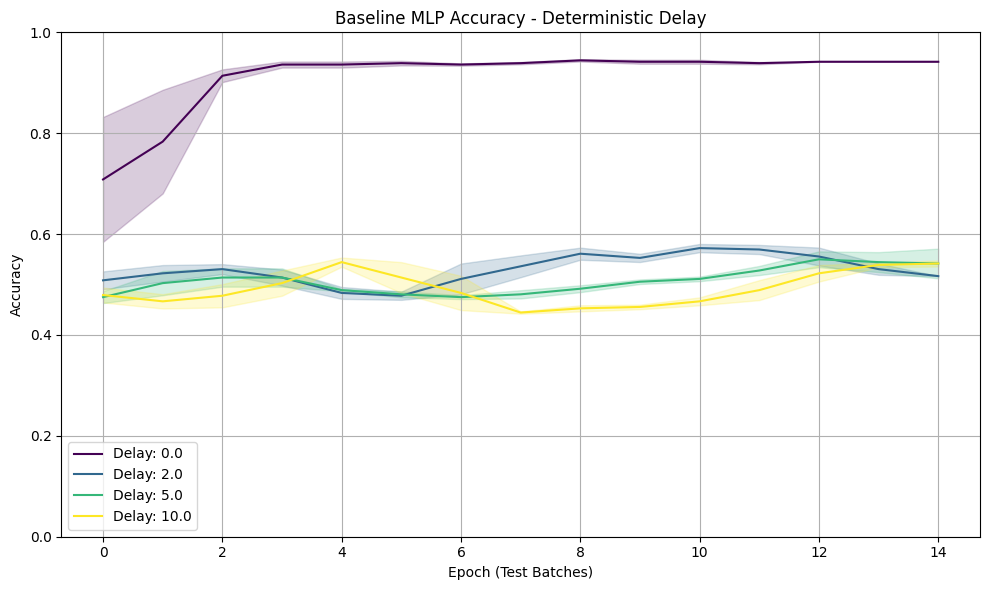

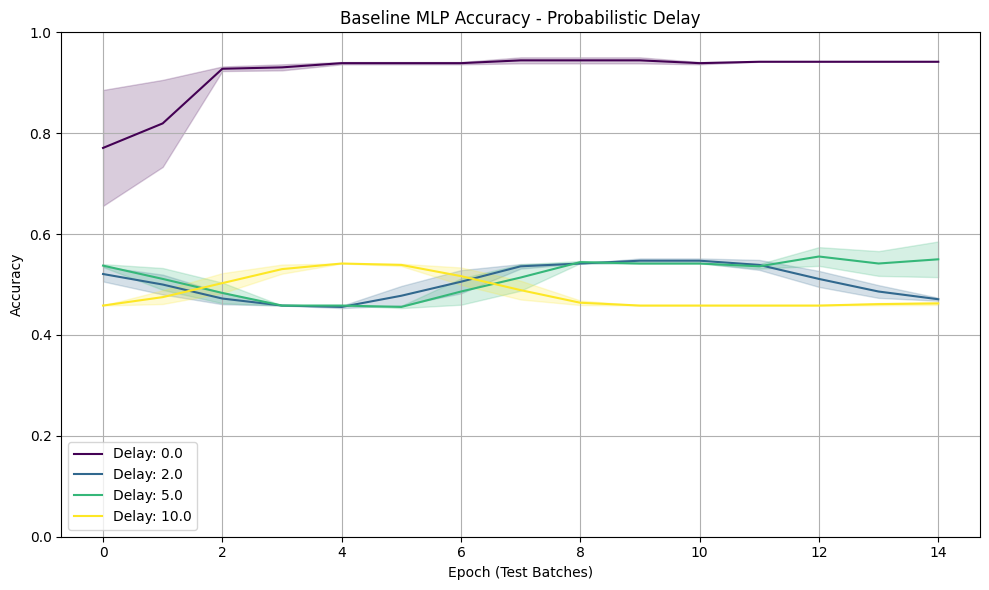

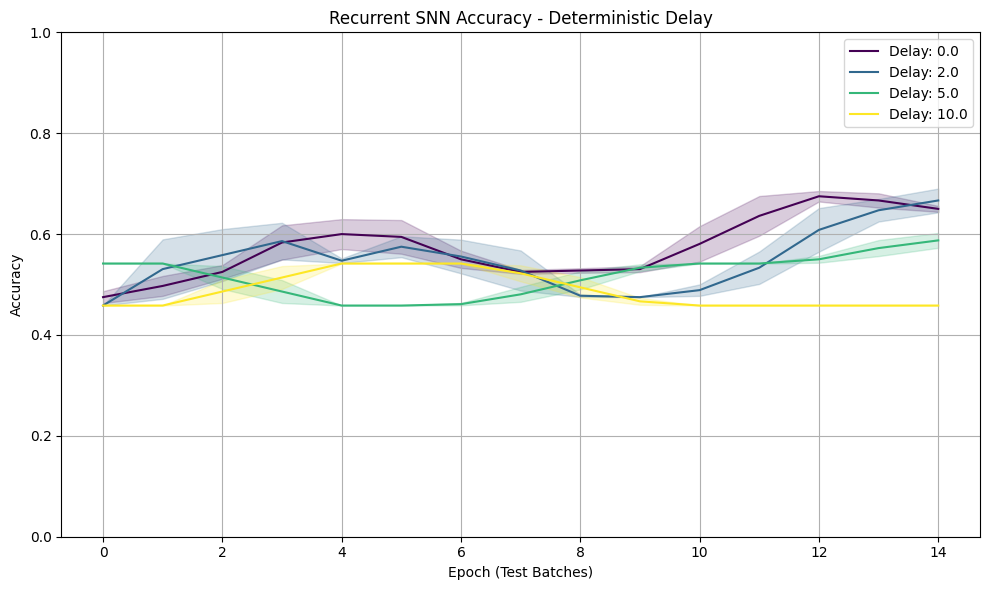

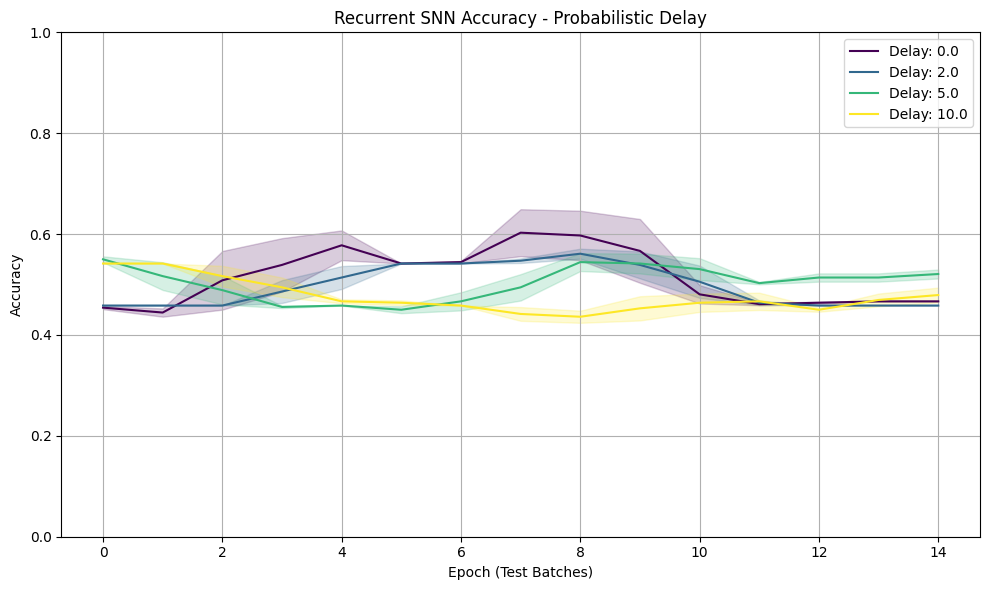

In [ ]:
#@title full experiment

import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 500
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 10 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 30          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0, 10.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, explicitly bridging the temporal gap.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate without next(iter()) which triggers StopIteration if empty
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.ylim([0, 1.0])
            plt.tight_layout()
            plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")